# EDA — Inspecciones estructurales (ArcGIS FeatureServer)

**Fuente:** capa pública de ArcGIS Survey123
`service_c9a79f2605a4455582d81c12ec3ba2f3_form/FeatureServer/0`.

Formulario de **evaluación de daño estructural** (alias de campos en hebreo, origen Israel).
Cada registro es la inspección de un edificio, con geometría de punto.
El campo clave es **`BldDetailedRate`**: nivel de daño asignado tras la revisión.
Decodificado, coincide con la escala EDE del proyecto:
**1 = apto para ocupación (habitable), 2 = peligroso (inseguro), 3 = uso restringido,
4 = apto con zonas peligrosas**.

Filtro del `where`: `BldDetailedRate is not NULL` (solo edificios ya etiquetados).

> EDA reproducible: descarga en vivo vía REST API, sin credenciales (token vacío).
> Las secciones 8-9 traducen el formulario y decodifican los valores a español.

## 1. Descarga de datos

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

BASE = ('https://services-eu1.arcgis.com/eeu6dGizBqA14mjm/ArcGIS/rest/services/'
        'service_c9a79f2605a4455582d81c12ec3ba2f3_form/FeatureServer/0')
WHERE = 'BldDetailedRate is not NULL'

def fetch_all(where=WHERE, page=1000):
    """Descarga todas las features paginando por resultOffset. Coords WGS84 (outSR=4326)."""
    feats, offset = [], 0
    while True:
        params = {'where': where, 'outFields': '*', 'returnGeometry': 'true',
                  'outSR': 4326, 'resultOffset': offset, 'resultRecordCount': page,
                  'f': 'json'}
        data = requests.get(BASE + '/query', params=params, timeout=60).json()
        batch = data.get('features', [])
        feats.extend(batch)
        if len(batch) < page or not data.get('exceededTransferLimit'):
            break
        offset += page
    return feats

features = fetch_all()
print(f'Features descargadas: {len(features)}')

Features descargadas: 101


## 2. Construcción del DataFrame

Aplanamos `attributes` + geometría (`lon`/`lat`) y convertimos las fechas (epoch ms) a `datetime`.

In [2]:
rows = []
for f in features:
    a = dict(f['attributes'])
    g = f.get('geometry') or {}
    a['lon'] = g.get('x')
    a['lat'] = g.get('y')
    rows.append(a)

df = pd.DataFrame(rows)
for col in ['surveyDate', 'CreationDate', 'EditDate']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], unit='ms', errors='coerce')

print(df.shape)
df.head(3)

(101, 66)


,objectid,globalid,Building_Address,surveyDate,surveyorNameTwo,ISBldFirstSurvey,BldFirstRate,remarks,bldUsageText,bldEssentialUsage,...,NeedActionRange,dangerousAreaMarked,dangerousAreaDesc,generalRemarks,CreationDate,Creator,EditDate,Editor,lon,lat
0,9,661cde6a-74ba-4081-b0e2-1e4ad07f8569,None,2026-08-16 21:35:07.819,גבי בן דוד,0,NaN,NaN,מוסד רפואי,1,...,2.0,1.0,NaN,חדרי המדרגות בבנין אזורים אדומים,2026-08-16 13:57:19.859,Agamimisr,2026-08-17 19:16:34.000,Engineer_ISR_1,-76.544436,3.418537
1,13,f5aa6d0b-e8dd-49a3-999d-7fad1b3f5806,None,2026-08-16 22:51:27.273,גבי בן דוד,0,NaN,Centro Medico Colmedica,מוסד רפואי,1,...,NaN,NaN,NaN,NaN,2026-08-16 13:57:19.859,Agamimisr,2026-08-16 22:53:40.035,Engineer_ISR_1,-76.543057,3.421565
2,16,6766a1a6-d520-4eed-9a45-963784cea4c0,None,2026-08-20 15:54:58.703,גבי בן דוד,0,NaN,Clinica Naturista San Rafael,מוסד רפואי,1,...,3.0,NaN,NaN,NaN,2026-08-16 13:57:19.859,Agamimisr,2026-08-20 17:01:00.723,Engineer_ISR_1,-76.544219,3.418314


## 3. Panorama general

In [3]:
print(f'Filas: {len(df)}  |  Columnas: {df.shape[1]}')
print(f"Rango de inspecciones: {df['surveyDate'].min()}  ->  {df['surveyDate'].max()}")
print(f"Inspectores distintos: {df['surveyorNameTwo'].nunique()}")

Filas: 101  |  Columnas: 66
Rango de inspecciones: 2026-08-16 15:40:34.290000  ->  2026-08-20 17:11:38.209000
Inspectores distintos: 7


In [4]:
compl = (df.notna().mean() * 100).round(1).sort_values()
compl.to_frame('% no nulo').head(20)

,% no nulo
Building_Address,0.0
NeedInfraImmediate,0.0
trappedChance,0.0
floorArea,0.0
BldFirstRate,1.0
buildingNonSkeleton,1.0
baseDmgExposure,2.0
baseDmgNoBldDitach,2.0
baseDmgGroundDistorNoBldDmg,2.0
baseDmgGroundDistortion,2.0


## 4. Variable objetivo: `BldDetailedRate` (nivel de daño)

Distribución de códigos (las etiquetas en español se aplican en la sección 9).

BldDetailedRate
1    58
2     8
3    21
4    14
Name: count, dtype: int64


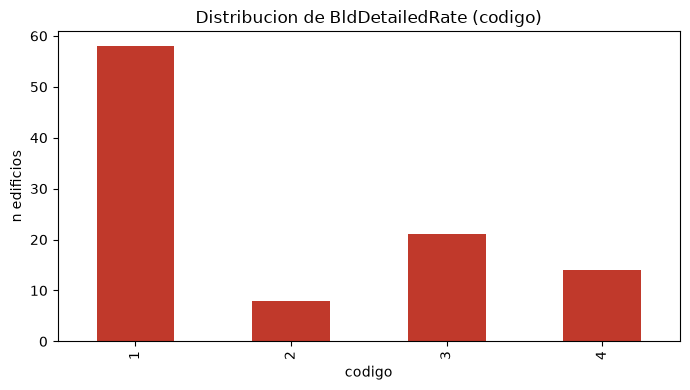

In [5]:
rate = df['BldDetailedRate'].value_counts(dropna=False).sort_index()
print(rate)
ax = rate.plot(kind='bar', color='#c0392b', figsize=(7, 4))
ax.set_title('Distribucion de BldDetailedRate (codigo)')
ax.set_xlabel('codigo'); ax.set_ylabel('n edificios')
plt.tight_layout(); plt.show()

## 5. Caracterización estructural

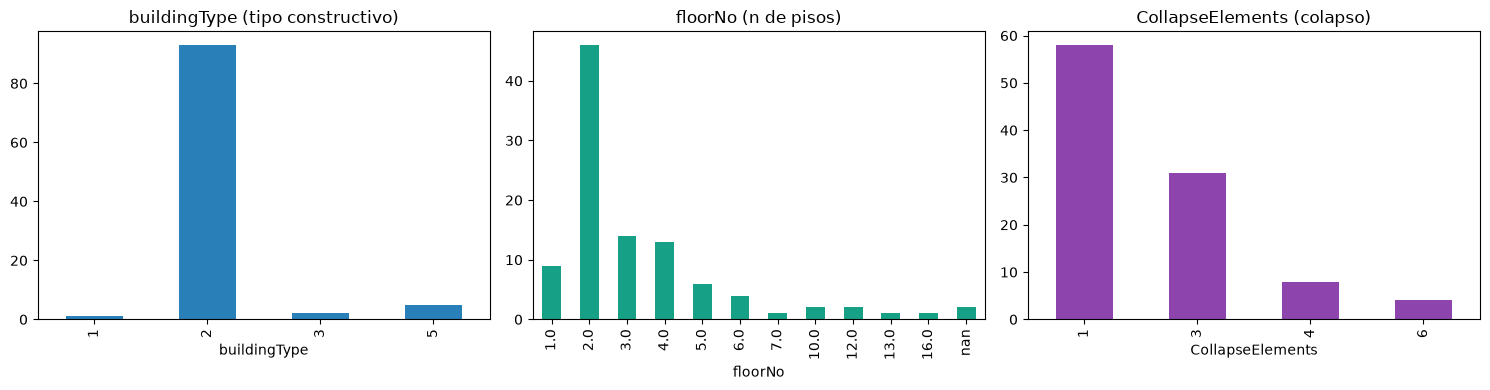

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['buildingType'].value_counts(dropna=False).sort_index().plot(kind='bar', ax=axes[0], color='#2980b9')
axes[0].set_title('buildingType (tipo constructivo)')
df['floorNo'].value_counts(dropna=False).sort_index().plot(kind='bar', ax=axes[1], color='#16a085')
axes[1].set_title('floorNo (n de pisos)')
df['CollapseElements'].value_counts(dropna=False).sort_index().plot(kind='bar', ax=axes[2], color='#8e44ad')
axes[2].set_title('CollapseElements (colapso)')
plt.tight_layout(); plt.show()

## 6. Banderas de riesgo / acción (campos 0/1)

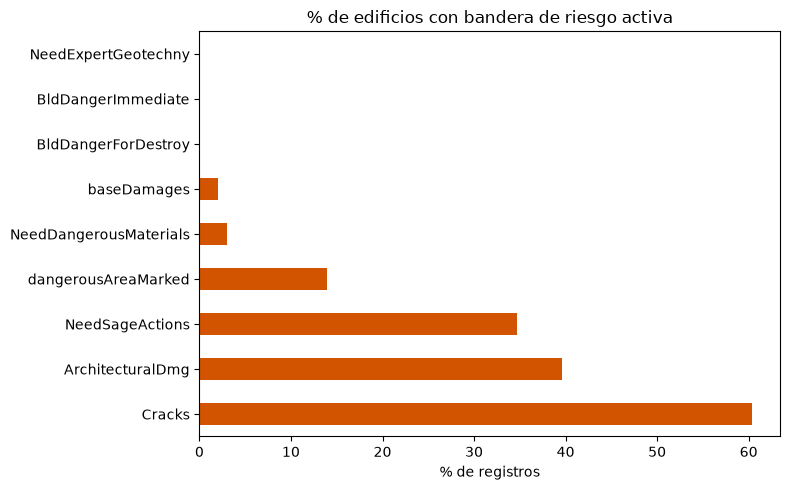

In [7]:
flags = ['BldDangerForDestroy', 'BldDangerImmediate', 'NeedExpertGeotechny',
         'NeedDangerousMaterials', 'NeedSageActions', 'baseDamages', 'Cracks',
         'ArchitecturalDmg', 'dangerousAreaMarked']
flags = [c for c in flags if c in df.columns]
resumen = (df[flags] == 1).mean().mul(100).round(1).sort_values(ascending=False)
ax = resumen.plot(kind='barh', figsize=(8, 5), color='#d35400')
ax.set_title('% de edificios con bandera de riesgo activa')
ax.set_xlabel('% de registros')
plt.tight_layout(); plt.show()

## 7. Distribución espacial

Puntos coloreados por `BldDetailedRate`, coordenadas en WGS84 (lon/lat).

Con coordenadas: 101 / 101


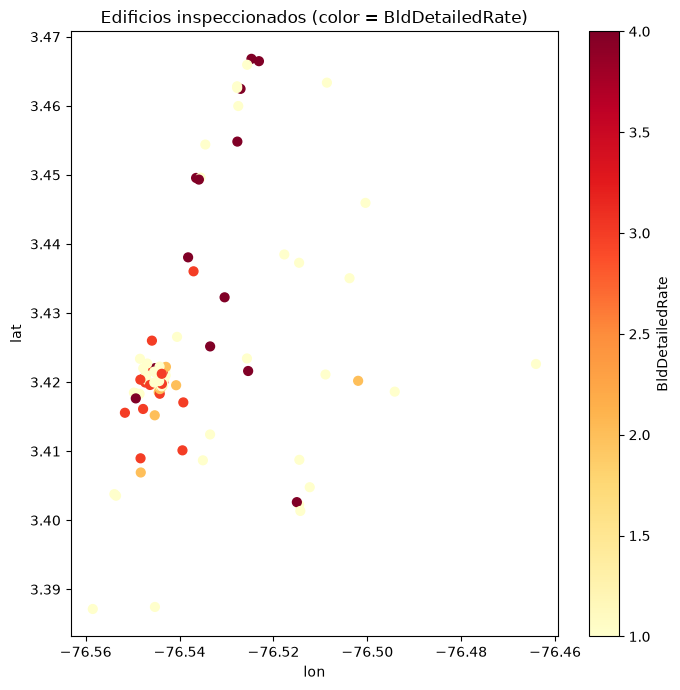

In [8]:
geo = df.dropna(subset=['lon', 'lat'])
print(f'Con coordenadas: {len(geo)} / {len(df)}')
ax = geo.plot.scatter(x='lon', y='lat', c='BldDetailedRate', cmap='YlOrRd',
                      s=40, figsize=(7, 7), colorbar=True)
ax.set_title('Edificios inspeccionados (color = BldDetailedRate)')
plt.tight_layout(); plt.show()

## 8. Diccionario de datos (hebreo → español)

El formulario original está en hebreo. Traemos los alias reales del servicio
(`/FeatureServer/0?f=json`) y los cruzamos con la traducción al español.

In [9]:
# Alias en hebreo, tomados en vivo del servicio
meta = requests.get(BASE, params={'f': 'json'}, timeout=60).json()
alias_he = {f['name']: f.get('alias') for f in meta['fields']}
coded_he = {f['name']: {str(cv['code']): cv['name'] for cv in f['domain']['codedValues']}
            for f in meta['fields']
            if (f.get('domain') or {}).get('type') == 'codedValue'}
print(f'Campos: {len(alias_he)}  |  con dominio codificado: {len(coded_he)}')

Campos: 64  |  con dominio codificado: 43


In [10]:
# Traduccion de alias de campo (hebreo -> espanol)
ALIAS_ES = {
    'Building_Address': 'Dirección',
    'surveyDate': 'Fecha y hora de la inspección',
    'surveyorNameTwo': 'Nombre del inspector',
    'ISBldFirstSurvey': '¿Se realizó inspección preliminar?',
    'BldFirstRate': 'Etiqueta de la inspección preliminar',
    'remarks': 'Observaciones',
    'bldUsageText': 'Uso del edificio',
    'bldEssentialUsage': '¿Uso esencial del edificio?',
    'bldEssentialUsageDesc': '¿Qué servicio esencial?',
    'buildingType': 'Método o tipo de construcción',
    'buildingNonSkeleton': 'Tipo de edificio sin estructura',
    'buildingBetonSkeleton': 'Tipo de edificio con estructura de hormigón',
    'buildingTypeOther': 'Otro tipo de edificio',
    'floorNo': 'Número de pisos',
    'floorArea': 'Área estimada de piso típico (m²)',
    'basementParking': '¿Existe sótano o parqueadero?',
    'basementParkingNo': 'N.º de pisos de sótano/parqueadero',
    'attachBuilding': '¿Edificaciones anexas?',
    'attachBuildingDesc': 'Detalle de edificaciones anexas',
    'scanAreaFullPartial': 'Área de inspección (total/parcial)',
    'scanAreaOuterInner': 'Área de inspección (exterior/interior)',
    'CollapseElements': 'Colapso/derrumbe de elementos o alas',
    'CollapseDesc': 'Descripción del colapso',
    'trappedChance': '¿Posibilidad de personas atrapadas?',
    'bldTendency': 'Inclinación del edificio o piso',
    'baseDamages': '¿Daño en terreno o cimentación?',
    'baseDmgGroundDistortion': 'Deformación del terreno solo local',
    'baseDmgGroundDistorNoBldDmg': 'Deformación extensa del terreno sin daño al edificio',
    'baseDmgNoBldDitach': 'Desprendimiento del edificio del terreno',
    'baseDmgExposure': 'Exposición de cimientos y riesgo',
    'baseDmgSignificantRisk': 'Daño significativo del terreno y riesgo',
    'Cracks': '¿Se detectaron grietas?',
    'CracksNegligible': 'Grietas de revoque/recubrimiento insignificantes',
    'CracksPeriferal': 'Grietas significativas en muros no estructurales',
    'cracksBeam': 'Grietas en columnas, vigas o muros de rigidización',
    'cracksDiagonal': 'Grietas de cortante diagonales cerca de nudos',
    'cracksPenetration': 'Grietas de punzonamiento alrededor de columnas',
    'cracksBending': 'Grietas de flexión en columnas o vigas',
    'cracksCritical': 'Otras grietas críticas',
    'cracksTromy': 'Fisuración en elementos prefabricados o sus nudos',
    'ArchitecturalDmg': '¿Daños críticos en elementos arquitectónicos?',
    'ArchitecturalDmgCover': 'Recubrimientos con riesgo para zonas exteriores',
    'ArchitecturalDmgOther': 'Elementos que podrían caer y representan riesgo',
    'ArchitecturalDmgCritical': 'Daño arquitectónico sustancial en zonas extensas',
    'BldDetailedRate': 'Etiqueta del edificio (inspección detallada)',
    'BldDangerForDestroy': '¿Peligroso y destinado a demolición?',
    'NeedExpertGeotechny': '¿Requiere experto geotécnico/suelos?',
    'NeedDangerousMaterials': '¿Requiere experto en materiales peligrosos?',
    'NeedExpertOther': '¿Requiere otros expertos?',
    'NeedSageActions': '¿Requiere obras para volver a estado seguro?',
    'BldDangerImmediate': '¿Riesgo de infraestructura para la vida inmediato?',
    'NeedInfraImmediate': 'Infraestructuras a atender de inmediato',
    'NeedActions': '¿Qué acciones se requieren?',
    'NeedActionsDesc': 'Descripción de acciones requeridas',
    'NeedActionRange': 'Alcance del trabajo requerido',
    'dangerousAreaMarked': '¿Se señalizaron las zonas peligrosas?',
    'dangerousAreaDesc': 'Descripción de zonas peligrosas',
    'generalRemarks': 'Observaciones generales',
}

dicc = pd.DataFrame({
    'campo': list(alias_he),
    'alias_hebreo': [alias_he[k] for k in alias_he],
    'alias_espanol': [ALIAS_ES.get(k, '') for k in alias_he],
})
dicc[dicc['alias_espanol'] != '']

,campo,alias_hebreo,alias_espanol
2,Building_Address,כתובת,Dirección
3,surveyDate,תאריך ושעת הסקר,Fecha y hora de la inspección
4,surveyorNameTwo,שם סוקר,Nombre del inspector
5,ISBldFirstSurvey,האם בוצע סקר ראשוני,¿Se realizó inspección preliminar?
6,BldFirstRate,התיוג שהתקבל בסקר ראשוני,Etiqueta de la inspección preliminar
7,remarks,הערות,Observaciones
8,bldUsageText,שימוש מבנה,Uso del edificio
9,bldEssentialUsage,שימוש מבנה חיוני,¿Uso esencial del edificio?
10,bldEssentialUsageDesc,איזה שירות חיוני,¿Qué servicio esencial?
11,buildingType,שיטה או סוג בנייה,Método o tipo de construcción


## 9. Decodificación de valores a español

Traducimos las etiquetas de los *coded value domains* (los códigos enteros → texto).
Los campos 0/1 se resuelven a **Sí/No**; los categóricos, a su etiqueta traducida.

In [11]:
SI_NO = {'1': 'Sí', '0': 'No'}

# Etiquetas en espanol por campo categorico (code -> texto)
CODED_ES = {
    'BldDetailedRate': {'1': 'Apto para ocupación', '2': 'Peligroso',
                        '3': 'Uso restringido', '4': 'Apto con zonas peligrosas'},
    'BldFirstRate': {'1': 'Apto para ocupación', '2': 'Peligroso',
                     '3': 'Uso restringido', '4': 'Apto con zonas peligrosas'},
    'buildingType': {'1': 'Sin estructura (mampostería)', '2': 'Estructura de hormigón',
                     '3': 'Estructura de acero', '4': 'Prefabricado completo', '5': 'Otro'},
    'buildingNonSkeleton': {'1': 'Piedra', '2': 'Bloque sin estructura de hormigón',
                            '3': 'Paneles livianos (fibrocemento, yeso)', '4': 'Ladrillo',
                            '5': 'Madera', '6': 'Solo elementos livianos'},
    'buildingBetonSkeleton': {'1': 'Moderno con muros de rigidización de hormigón',
                              '2': 'Pórticos de hormigón con muros de bloque',
                              '3': 'Hormigón con planta libre (piso blando)',
                              '4': 'Hormigón con muros de rigidización',
                              '5': 'Hormigón con elementos prefabricados'},
    'scanAreaFullPartial': {'1': 'Todo el edificio', '2': 'Parte del edificio'},
    'scanAreaOuterInner': {'1': 'Solo exterior', '2': 'Exterior e interior'},
    'CollapseElements': {'1': 'Sin derrumbe',
                         '2': 'Derrumbe total (sitio destruido)',
                         '3': 'Caída leve de elementos (riesgo solo local)',
                         '4': 'Caída de elementos significativos',
                         '5': 'Derrumbe de ala/piso/zona extensa (peligro sustancial)',
                         '6': 'Derrumbe local sin efecto en el resto'},
    'trappedChance': {'1': 'Desconocido', '2': 'Sin atrapados', '3': 'Hay atrapados'},
    'bldTendency': {'0': 'Sin inclinación significativa', '1': 'Inclinación grave visible'},
    'NeedInfraImmediate': {'1': 'Electricidad', '2': 'Gas', '3': 'Agua', '4': 'Saneamiento'},
    'NeedActions': {'1': 'No se requiere', '2': 'Desalojo/limpieza básica (manual)',
                    '3': 'Reparaciones básicas', '4': 'Retiro de elementos pesados (maquinaria)'},
    'NeedActionRange': {'1': 'Pocos días de cuadrilla', '2': '~2 semanas de reparación básica',
                        '3': 'Reparación extensa (construir elementos estructurales)',
                        '4': 'Maquinaria pesada, demolición y reconstrucción'},
}
# Los demas campos con dominio son binarios Sí/No
for c in coded_he:
    CODED_ES.setdefault(c, SI_NO)

def decode(col):
    m = CODED_ES.get(col, {})
    return df[col].map(lambda v: m.get(str(int(v))) if pd.notna(v) else None)

# Columnas decodificadas para los campos clave
for c in ['BldDetailedRate', 'buildingType', 'CollapseElements', 'NeedActions', 'NeedActionRange']:
    df[c + '_es'] = decode(c)

df[['BldDetailedRate', 'BldDetailedRate_es', 'CollapseElements_es', 'NeedActions_es']].head(8)

,BldDetailedRate,BldDetailedRate_es,CollapseElements_es,NeedActions_es
0,2,Peligroso,Sin derrumbe,Reparaciones básicas
1,1,Apto para ocupación,Sin derrumbe,NaN
2,3,Uso restringido,Caída de elementos significativos,Reparaciones básicas
3,3,Uso restringido,Sin derrumbe,NaN
4,1,Apto para ocupación,Sin derrumbe,NaN
5,2,Peligroso,Caída leve de elementos (riesgo solo local),NaN
6,1,Apto para ocupación,Sin derrumbe,NaN
7,1,Apto para ocupación,Sin derrumbe,NaN


### 9.1 Nivel de daño con etiquetas en español

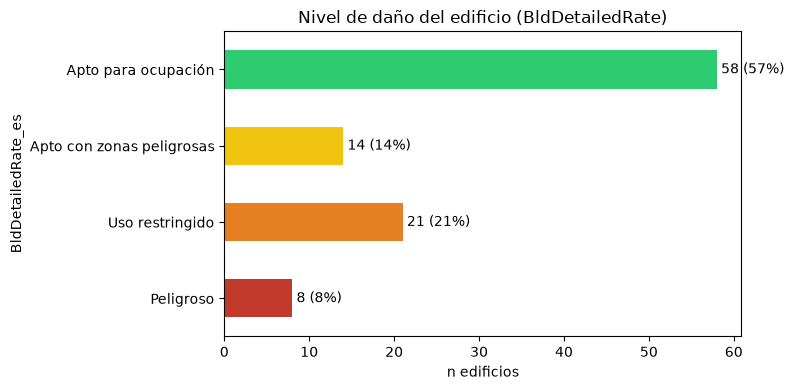

In [12]:
orden = ['Apto para ocupación', 'Apto con zonas peligrosas', 'Uso restringido', 'Peligroso']
vc = df['BldDetailedRate_es'].value_counts().reindex(orden).dropna()
colores = {'Apto para ocupación': '#2ecc71', 'Apto con zonas peligrosas': '#f1c40f',
           'Uso restringido': '#e67e22', 'Peligroso': '#c0392b'}
ax = vc.plot(kind='barh', figsize=(8, 4), color=[colores[i] for i in vc.index])
for i, v in enumerate(vc.values):
    ax.text(v + 0.5, i, f'{v} ({v/len(df)*100:.0f}%)', va='center')
ax.set_title('Nivel de daño del edificio (BldDetailedRate)')
ax.set_xlabel('n edificios'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

### 9.2 Estado de colapso y acciones requeridas (en español)

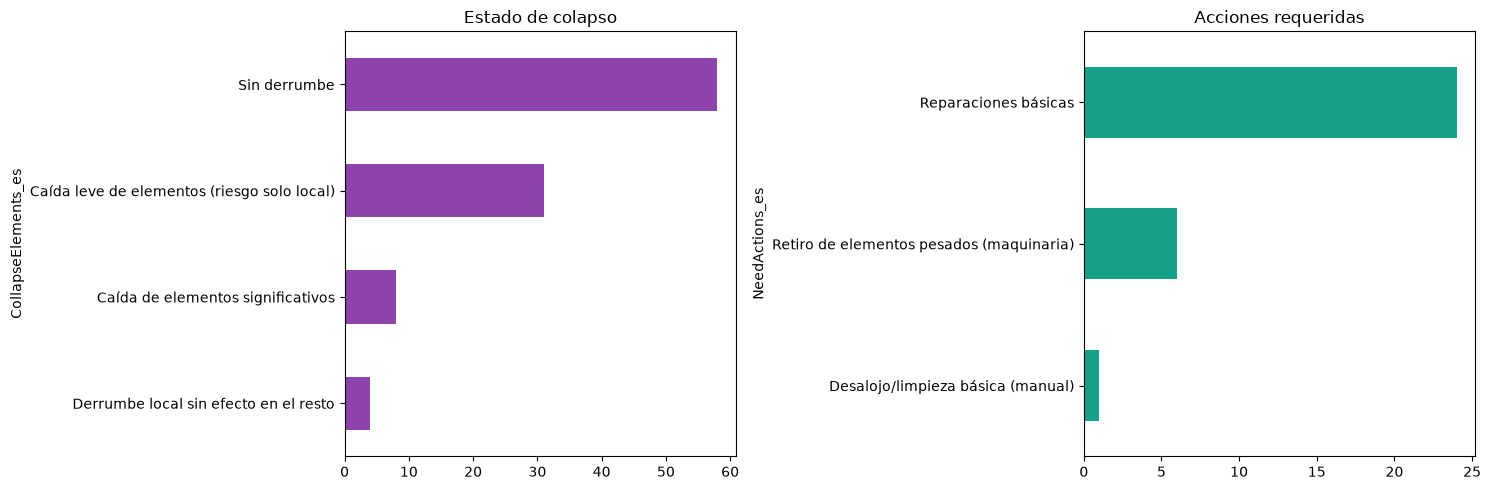

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df['CollapseElements_es'].value_counts().plot(kind='barh', ax=axes[0], color='#8e44ad')
axes[0].set_title('Estado de colapso'); axes[0].invert_yaxis()
df['NeedActions_es'].value_counts().plot(kind='barh', ax=axes[1], color='#16a085')
axes[1].set_title('Acciones requeridas'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

### 9.3 Cruce: nivel de daño × destinado a demolición

In [14]:
ct = pd.crosstab(df['BldDetailedRate_es'],
                 df['BldDangerForDestroy'].map(lambda v: SI_NO.get(str(int(v))) if pd.notna(v) else None),
                 dropna=False)
ct.columns = [f'demolición: {c}' for c in ct.columns]
ct

,demolición: No,demolición: nan
BldDetailedRate_es,,
Apto con zonas peligrosas,0,14
Apto para ocupación,0,58
Peligroso,6,2
Uso restringido,0,21


## 10. Remapeo al esquema EDE de Cali

El módulo `israel_to_cali.py` traduce los campos israelíes a los nombres y
vocabularios `snake_case` del survey de Cali (`refresh_data.py`) y **reindexa al
esquema completo** de `inspections.json`: el DataFrame resultante tiene exactamente
las mismas columnas normalizadas que el primer survey (los campos sin equivalente
quedan en `None`). Incluye renames directos, recodificación de dominios y
derivaciones multi-campo (grietas→`danos_estructura`, base→`suelo_inestable`,
colapso→`nivel_dano`/`severidad_danos`, expertos→`requiere_evaluacion_adicional`).
El resultado se guarda en `puntos_israel_cali.json`.

> El color de habitabilidad (verde/amarillo/rojo) es el mapeo robusto; el código EDE
> fino (i1/i2/i3, r1/r2) es la mejor aproximación desde la escala israelí de 4 niveles.

In [15]:
import israel_to_cali
israel_to_cali.selfcheck()

schema = israel_to_cali.cali_schema()   # columnas del primer survey (inspections.json)
cali = israel_to_cali.remap(df, target_cols=schema)   # df tiene los campos crudos israelíes
cali = israel_to_cali.fill_comuna_barrio(cali)   # comuna/barrio_geo desde basemaps crudos
con_dato = [c for c in cali.columns if cali[c].notna().any()]
print(f'Esquema Cali: {len(schema)} columnas | con dato: {len(con_dato)} | vacías: {len(cali.columns) - len(con_dato)}')
print(f"comuna/barrio con match: {cali['comuna'].notna().sum()}/{len(cali)}")
cali[['entidad', 'fecha_inspeccion', 'municipio', 'comuna', 'barrio_geo',
      'criterio_habitabilidad', 'criterio_color', 'nivel_dano',
      'sistema_estructural', 'danos_estructura']].head(8)

israel_to_cali self-check OK


Esquema Cali: 125 columnas | con dato: 44 | vacías: 83
comuna/barrio con match: 101/101


,entidad,fecha_inspeccion,municipio,comuna,barrio_geo,criterio_habitabilidad,criterio_color,nivel_dano,sistema_estructural,danos_estructura
0,Inspectores de Israel,2026-08-16,Cali,COMUNA 19,Urbanización Tequendama,i2,rojo,medio,porticos,moderado
1,Inspectores de Israel,2026-08-16,Cali,COMUNA 19,Urbanización Tequendama,h,verde,sin_dano,porticos,sin_dano
2,Inspectores de Israel,2026-08-20,Cali,COMUNA 19,Urbanización Tequendama,r2,amarillo,alto,porticos,severo
3,Inspectores de Israel,2026-08-16,Cali,COMUNA 19,Urbanización Tequendama,r2,amarillo,sin_dano,porticos,sin_dano
4,Inspectores de Israel,2026-08-19,Cali,COMUNA 19,Urbanización Tequendama,h,verde,bajo,porticos,leve
5,Inspectores de Israel,2026-08-16,Cali,COMUNA 19,Urbanización Tequendama,i2,rojo,sin_dano,porticos,sin_dano
6,Inspectores de Israel,2026-08-16,Cali,COMUNA 19,Urbanización Tequendama,h,verde,sin_dano,porticos,sin_dano
7,Inspectores de Israel,2026-08-16,Cali,COMUNA 19,Urbanización Tequendama,h,verde,sin_dano,porticos,sin_dano


In [16]:
# BldDetailedRate original -> criterio_habitabilidad + color de Cali
chk = df[['BldDetailedRate']].copy()
chk['criterio_habitabilidad'] = cali['criterio_habitabilidad']
chk['criterio_color'] = cali['criterio_color']
pd.crosstab(chk['BldDetailedRate'],
            [chk['criterio_habitabilidad'], chk['criterio_color']])

criterio_habitabilidad,h,i2,r1,r2
criterio_color,verde,rojo,amarillo,amarillo
BldDetailedRate,,,,
1,58,0,0,0
2,0,8,0,0
3,0,0,0,21
4,0,0,14,0


## 11. Compatibilidad con el dashboard

El dashboard (`web/js/data.js` → `main.js`) consume `web/data/inspections.json`. Verificamos
el contrato real que espera:

1. **Campos requeridos** para pintar en el mapa y abrir el detalle: `x`/`y` numéricos y
   **`ObjectID`** (la *key* load-bearing: marcador, modal de detalle, fila de tabla — no
   `id_edan` ni `GlobalID`). Se genera como `isr-<n>` para no colisionar si se fusiona.
2. **Esquema**: los nombres de columna existen en `inspections.json`.
3. **Dominios de valor**: los valores caen dentro del vocabulario que el dashboard maneja
   (el color de habitabilidad se **calcula** de `criterio_habitabilidad`, no se lee un campo).

In [17]:
import json
cali_recs = json.loads(open('web/data/inspections.json', encoding='utf-8').read())
cali_cols = set().union(*[set(r) for r in cali_recs])

# (1) campos REQUERIDOS por el render/detalle del dashboard
x_ok = pd.to_numeric(cali['x'], errors='coerce').notna()
y_ok = pd.to_numeric(cali['y'], errors='coerce').notna()
oid = cali['ObjectID']
print(f'x/y numéricos (pintan en mapa): {int((x_ok & y_ok).sum())}/{len(cali)}')
print(f'ObjectID presente: {oid.notna().sum()}/{len(cali)} | únicos: {oid.nunique()} | ej: {oid.iloc[0]}')
cali_oids = {str(r.get('ObjectID')) for r in cali_recs}
print(f'¿ObjectID colisiona con los de Cali?: {bool(set(map(str, oid.dropna())) & cali_oids)}  (prefijo isr- lo evita)')

x/y numéricos (pintan en mapa): 101/101
ObjectID presente: 101/101 | únicos: 101 | ej: isr-9
¿ObjectID colisiona con los de Cali?: False  (prefijo isr- lo evita)


In [18]:
# (2) esquema: ¿todas las columnas del dashboard están presentes?
faltan = [c for c in cali_cols if c not in cali.columns]
print('Columnas del dashboard ausentes en el df:', faltan or 'ninguna ✓')
print('Extras que el dashboard ignora (no rompen):', [c for c in cali.columns if c not in cali_cols])

Columnas del dashboard ausentes en el df: ninguna ✓
Extras que el dashboard ignora (no rompen): ['criterio_color', 'fuente']


In [19]:
# (3) dominios de valor: enums israelíes ⊆ vocabulario que el dashboard maneja.
# OJO: comuna/barrio_geo NO se validan aquí — se unen contra los POLÍGONOS del
# geojson, no contra los valores de otras inspecciones (ver celda siguiente).
def dom(recs, col):
    return {str(r[col]) for r in recs if r.get(col) not in (None, '') and str(r.get(col)) != 'nan'}

CATEG = ['criterio_habitabilidad', 'nivel_dano', 'severidad_danos', 'sistema_estructural',
         'material_estructura', 'colapso_total', 'colapso_parcial', 'asentamiento_severo',
         'inclinacion_importante', 'suelo_inestable', 'riesgo_caida', 'alc_exterior',
         'alc_interior', 'uso_edificacion', 'municipio', 'tipo_evento']
filas = []
for col in CATEG:
    di = {str(v) for v in cali[col].dropna().unique()}
    fuera = sorted(di - dom(cali_recs, col))
    filas.append({'campo': col, 'n_valores': len(di),
                  'fuera_de_dominio': ', '.join(fuera) if fuera else '—',
                  'compatible': '✓' if not fuera else '✗'})
compat = pd.DataFrame(filas)
print('Campos con valores fuera de vocabulario:', int((compat['compatible'] == '✗').sum()))
compat

Campos con valores fuera de vocabulario: 0


,campo,n_valores,fuera_de_dominio,compatible
0,criterio_habitabilidad,4,—,✓
1,nivel_dano,4,—,✓
2,severidad_danos,4,—,✓
3,sistema_estructural,3,—,✓
4,material_estructura,3,—,✓
5,colapso_total,1,—,✓
6,colapso_parcial,2,—,✓
7,asentamiento_severo,1,—,✓
8,inclinacion_importante,2,—,✓
9,suelo_inestable,2,—,✓


In [20]:
# comuna/barrio_geo: compatibles si unen contra los polígonos del choropleth
def poly_names(path, key='name'):
    import os
    if not os.path.exists(path):
        return set()
    return {ft['properties'].get(key) for ft in json.load(open(path, encoding='utf-8'))['features']}

comu_poly = poly_names('web/data/comunas.geojson')
barr_poly = poly_names('web/data/barrios.geojson')
comu_miss = sorted(set(cali['comuna'].dropna()) - comu_poly) or 'ninguna ✓'
barr_miss = sorted(set(cali['barrio_geo'].dropna()) - barr_poly) or 'ninguno ✓'
n_comuna = int(cali['comuna'].notna().sum())
n_barrio = int(cali['barrio_geo'].notna().sum())
print(f'comuna: {n_comuna}/{len(cali)} con valor | sin polígono para unir: {comu_miss}')
print(f'barrio_geo: {n_barrio}/{len(cali)} con valor | sin polígono para unir: {barr_miss}')
print('(comunas/barrios que Cali nunca inspeccionó igual unen contra el geojson y colorean el mapa)')

comuna: 101/101 con valor | sin polígono para unir: ninguna ✓
barrio_geo: 101/101 con valor | sin polígono para unir: ninguno ✓
(comunas/barrios que Cali nunca inspeccionó igual unen contra el geojson y colorean el mapa)


### Ajustes y hallazgos de compatibilidad

- **`ObjectID` agregado** (`isr-<n>`): era el único campo faltante que rompía algo
  (el modal *Ver detalle* del dashboard usa `String(ObjectID)`). Prefijo `isr-` evita
  colisión con los ObjectID enteros de Cali (2–719) si se fusiona en `inspections.json`.
- **`comuna` = `"COMUNA 19"`**: formato exacto que el choropleth une contra
  `comunas.geojson` (match sin normalizar). Cualquier otro formato (`"19"`, `"Comuna 19"`)
  no colorearía el polígono — verificado OK.
- **`suspension_servicios`** lo **recalcula** el dashboard al cargar (colapso_total + no
  habitable); el valor que exportamos se sobrescribe. No molesta, pero no es autoritativo.
- **`criterio_color`, `fuente`, `x_form`, `y_form`**: extras que el dashboard ignora
  (el color se calcula de `criterio_habitabilidad`). No rompen; se vuelven buscables.
- **`entidad = "Inspectores de Israel"`**: valor nuevo en un selector aditivo — suma una
  opción de filtro, no rompe. Es el identificador pedido para distinguir esta fuente.
- **No mapeables** (el form israelí no los captura): `afectacion_planta`, `n_ocupantes`,
  `epoca_construccion`, `41_a..46_c` — quedan vacíos; el dashboard los trata como *sin dato*.

## 12. Notas y limitaciones

- **Traducción:** los alias y las etiquetas de dominio se traducen en las secciones 8-9;
  el hebreo original se trae en vivo del servicio, así que el cruce es verificable.
- **Escala de daño:** `BldDetailedRate` decodificado equivale a la escala EDE del proyecto
  (habitable / restringido / inseguro), lo que permite comparar metodologías.
- **Nombres de inspectores:** quedan en hebreo (son identificadores, no se traducen).
- **Volumen chico:** ~97 registros; distribuciones indicativas, no robustas estadísticamente.
- **Token vacío:** la capa respondió sin credenciales; si a futuro exige token, agregarlo a `params`.